## Sanity Check dos dados

Esse notebook faz parte do Tech Challenge da primeira fase da pós graduação de AI Scientist da FIAP. 

Esse projeto propõe que o grupo realize uma análise da base de dados de NPS de um e-commerce, buscando entender padrões que mais influenciam para tornar clientes promotores e detratores, sendo capaz de direcionar o time de negócios e tomada de decisões que buscam melhorar a experiência do cliente. 

O contexto, escopo e as métricas de avaliação desse projeto foram definidos anteriormente em outro documento. O objetivo desse notebook é realizar um Sanity Check dos dados, avaliando a sua qualidade e identificando possíveis inconsistências que podem prejudicar as análises futuras. 

**Fontes de dados**

- **desafio_nps_fase_1.csv:** arquivo CSV com as informações de clientes, pedidos e a nota NPS atribuída pelo cliente daquele pedido.

**Principais insights**

- A base tem 2500 linhas e 19 colunas. 
- Cada linha identifica uma ordem (pedido), e acompanha as informações do cliente como idade e região, informações da ordem como valor, desconto, tempo de entrega, e a nota NPS atribuída aquela ordem. 
- Não foram encontrados valores nulos em nenhuma coluna da base.
- A coluna **order_id** é a chave da tabela. Ela identifica a ordem. Não existem duplicadas de ordens na tabela, ela é 100% única.
- 91.3% dos pedidos não foram comprados novamente 30 dias após a sua compra, ou seja, somente 8.7% dos pedidos foram feitos novamente em um intervalo de 30 dias após o pedido. Essa distribuição concentrada pode ser natural e o produto realmente tem um giro superior a 30 dias, sendo incomum uma compra depois de 30 dias. Porém isso também pode apontar um problema de negócio, que o cliente estava insatisfeito com o produto ou com a marca e não repetiu o pedido por não estar satisfeito com ele. 
- A maioria das ordens está representada em valores menores, com 75% delas com valor de até 577 reais. 
- Não existem uma única ordem com nenhum desconto, o menor valor de desconto é 0.02, praticamente 0, mas toda ordem teve ao menos um centavo de desconto. 
- Distribuição normal do NPS, com uma leve exceção na nota 0, que possui uma concentração maior. Média e mediana por volta de 4.4. 
- Considerando os intervalos de notas de NPS, grande maioria dos clientes são detratores. 
- Score interno parece ser "confirmado" pela nota do cliente. 

**Pontos de atenção**

- Existem 35 ordens em que o valor de desconto é superior ao valor da ordem.
- A maioria dos pedidos teve algum atraso.
- A maioria dos pedidos necessitaram de mais de uma tentativa de entrega.  
- Média de 4 reclamações registradas por pedido, número que, de imediato, parece ser bem significativo. 

### 0. Imports

In [1]:
import sys
import os
import pandas as pd
root = os.path.dirname(os.path.dirname(os.getcwd()))

sys.path.append(os.path.join(root, 'src'))
from utils.sanity_utils import *

### 1. Geração de parâmetros

In [2]:
par_source_nps = "desafio_nps_fase_1.csv"

### 2. Leitura dos dados

In [3]:
df_nps = pd.read_csv(os.path.join(root, f"dados/raw/{par_source_nps}"))

### 3. Visão Geral dos dados

#### 3.1. Visualização

In [4]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


#### 3.2. Tamanho

In [5]:
tamanho = df_nps.shape[0]

print(f"Tamanho da base: {tamanho} linhas")
print(f"Tamanho da base: {len(df_nps.columns)} Colunas")

Tamanho da base: 2500 linhas
Tamanho da base: 19 Colunas


#### 3.3. Schema

In [6]:
df_nps.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

**Conclusões**

- A base tem 2500 linhas e 19 colunas. 
- Cada linha identifica uma ordem (pedido), e acompanha as informações do cliente como idade e região, informações da ordem como valor, desconto, tempo de entrega, e a nota NPS atribuída aquela ordem. 

### 4. Valores Ausentes

In [7]:
avalia_valores_nulos(df_nps)

,QTD_NULOS,%_NULOS
customer_id,0,0.0
customer_age,0,0.0
customer_region,0,0.0
customer_tenure_months,0,0.0
order_id,0,0.0
order_value,0,0.0
items_quantity,0,0.0
discount_value,0,0.0
payment_installments,0,0.0
delivery_time_days,0,0.0


**Conclusões**

- Não foram encontrados valores nulos em nenhuma coluna da base.

### 5. Valores Distintos

In [8]:
avalia_valores_distintos(df_nps)

,QTD_DISTINTOS,%_DISTINTOS
customer_id,2500,1.0000
customer_age,52,0.0208
customer_region,5,0.0020
customer_tenure_months,119,0.0476
order_id,2500,1.0000
order_value,2457,0.9828
items_quantity,6,0.0024
discount_value,2050,0.8200
payment_installments,11,0.0044
delivery_time_days,13,0.0052


**Conclusões**

- A coluna **order_id** é a chave da tabela. Ela identifica a ordem. Não existem duplicadas de ordens na tabela, ela é 100% única.
- Não existem duplicadas de clientes na tabela, toda as ordens foram feitas por clientes distintos. 
- No total, temos 101 notas distintas de NPS. 

### 6. Valores Duplicados

In [9]:
avalia_duplicadas(df_nps)

0

**Conclusões**

- Dado que as colunas **order_id** e **customer_id** são 100% únicas, já era esperado que não houvessem duplicadas na base.

### 7. Definição e Categorização de colunas

In [10]:
df_nps.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

In [11]:
colunas_id = ['customer_id', 'order_id']
colunas_categoricas = ['customer_region', 'repeat_purchase_30d']
colunas_numericas = ['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments',
                     'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts',
                     'resolution_time_days', 'nps_score', 'complaints_count', 'csat_internal_score']

### 8. Colunas de identificação

#### 8.1. customer_id

In [12]:
col = "customer_id"

In [13]:
obter_tab_freq_abs(df_nps, col)

Tabela de frequencias


,freq_absoluta,count,freq_relativa
0,1,2500,0.0


**Conclusões**

- Como apontando anteriormente, não existem duplicatas de clientes na tabela, toda ordem avalida foi feita por clientes distintos. 

#### 8.2. order_id

In [14]:
col = "order_id"

In [15]:
obter_tab_freq_abs(df_nps, col)

Tabela de frequencias


,freq_absoluta,count,freq_relativa
0,1,2500,0.0


**Conclusões**

- **order_id** é a chave da tabela. Como visto anteriormente, ela é 100% distinta, ou seja, a mesma ordem não foi avaliada duas vezes, o que é correto e não apresenta nenhum tipo de inconsistência.

### 9. Colunas categóricas

#### 9.1. customer_region

In [16]:
col = "customer_region"

In [17]:
obter_tab_freq(df_nps, col)

Tabela de frequencias


,customer_region,freq_absoluta,freq_relativa
0,Sul,521,0.21
1,Sudeste,520,0.21
2,Norte,506,0.20
3,Nordeste,485,0.19
4,Centro-Oeste,468,0.19


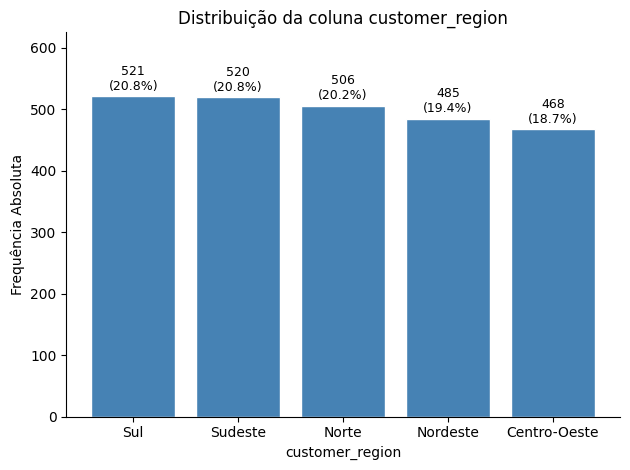

In [18]:
plota_bar(df_nps, col)

**Conclusão**

- Distribuição bem uniforme dos dados. Nenhuma região é muito mais presente na pesquisa de NPS do que outra. 
- A região com maior número de pedidos avaliados é o Sul, com 521 avaliações (20.8%), enquanto o Centro-Oeste é a com o menor número de pedidos avaliados (468 pedidos - 18.7%)

#### 9.2. repeat_purchase_30d

In [19]:
col = "repeat_purchase_30d"

In [20]:
obter_tab_freq(df_nps, col)

Tabela de frequencias


,repeat_purchase_30d,freq_absoluta,freq_relativa
0,0,2282,0.91
1,1,218,0.09


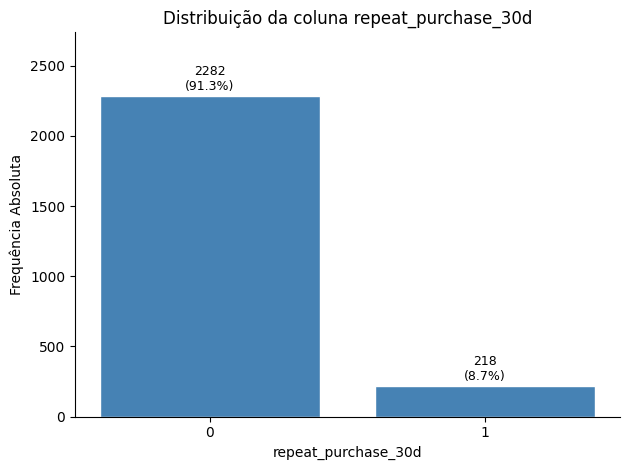

In [21]:
plota_bar(df_nps, col)

**Conclusão**

- 91.3% dos pedidos não foram comprados novamente 30 dias após a sua compra, ou seja, somente 8.7% dos pedidos foram feitos novamente em um intervalo de 30 dias após o pedido. 
- Essa distribuição concentrada pode ser natural e o produto realmente tem um giro superior a 30 dias, sendo incomum uma compra depois de 30 dias. Porém isso também pode apontar um problema de negócio, que o cliente estava insatisfeito com o produto ou com a marca e não repetiu o pedido por não estar satisfeito com ele. 

### 10. Colunas numéricas

#### 10.1. customer_age

In [22]:
col = "customer_age"

In [23]:
df_nps[col].describe().to_frame()

,customer_age
count,2500.000000
mean,43.396000
std,14.888487
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


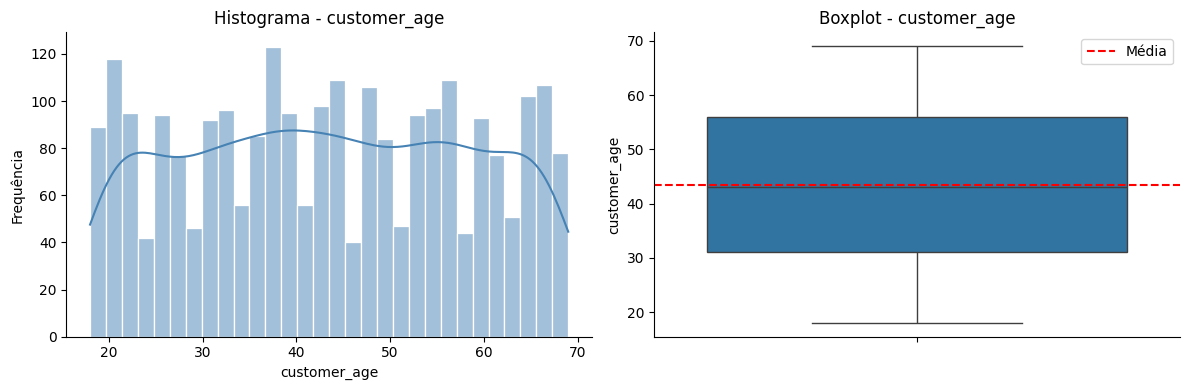

In [24]:
plota_histograma_e_boxplot(df_nps, col)

**Conclusões**

- Sem valores absurdos, o cliente mais novo possui 18 anos e o mais velho 69 anos.
- Não parece haver uma concentração em uma faixa etária específica, os produtos oferecidos são comprados tanto por clientes mais jovens quanto por clientes mais velhos, com uma média e mediana por volta dos 43 anos.
- **Tratamentos:** Vale a pena a construção de uma coluna de faixa etária.

#### 10.2. customer_tenure_months

In [25]:
col = "customer_tenure_months"

In [26]:
df_nps[col].describe().to_frame()

,customer_tenure_months
count,2500.000000
mean,61.322400
std,34.478729
min,1.000000
25%,31.000000
50%,62.000000
75%,91.000000
max,119.000000


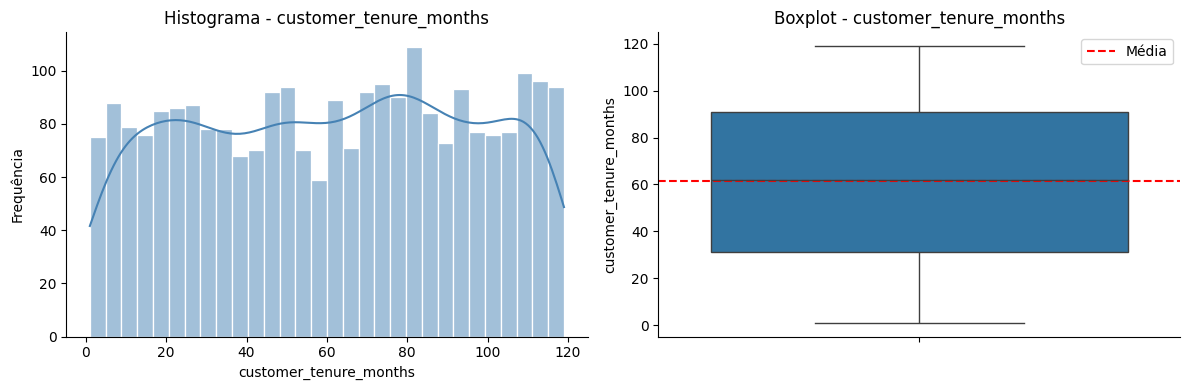

In [27]:
plota_histograma_e_boxplot(df_nps, col)

**Conclusões**

- Essa coluna indica o tempo de relacionamento do cliente com a empresa. 
- Distribuição bem uniforme dos dados, não parece haver uma concentração em clientes novos ou antigos na base.
- A média e a mediana estão por volta dos 61 meses, ou seja, 5 anos de relacionamento. 

#### 10.3. order_value

In [28]:
col = "order_value"

In [29]:
df_nps[col].describe().to_frame()

,order_value
count,2500.000000
mean,434.259740
std,289.772497
min,7.760000
25%,220.245000
50%,375.515000
75%,577.290000
max,1983.810000


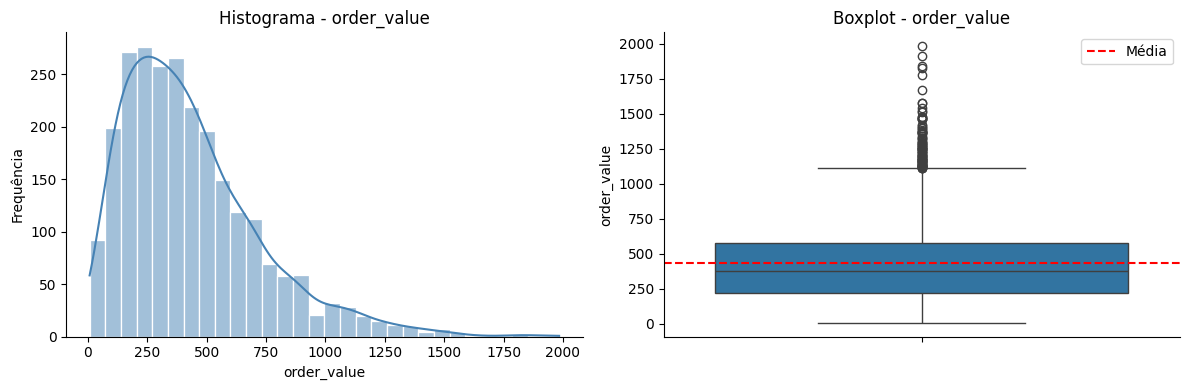

In [30]:
plota_histograma_e_boxplot(df_nps, col)

**Conclusões**

- Distribuição normal, assimétrica a esquerda, com alguns outliers a direita. 
- A maioria das ordens está representada em valores menores, com 75% delas com valor de até 577 reais. 
- Média de R$434, jogada um pouco para cima devido a presença de outliers, se comparada a mediana de R$375.
- Algumas compras maiores (valor superior a R$1000) são encontradas na base, mas são minoria.

#### 10.4. items_quantity

In [31]:
col = "items_quantity"

In [32]:
df_nps[col].describe().to_frame()

,items_quantity
count,2500.000000
mean,3.470800
std,1.687331
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


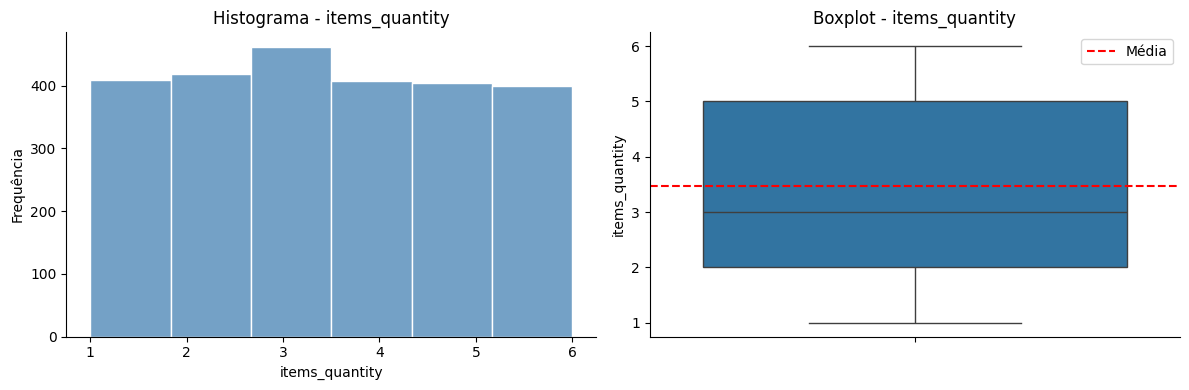

In [33]:
plota_histograma_e_boxplot(df_nps, col, 6, False)

**Conclusão**

- Distribuição uniforme, não existe uma concentração em uma quantidade específica de itens.
- O número mínimo de itens é 1 e o máximo é 6.

#### 10.5. discount_value

In [34]:
col = "discount_value"

In [35]:
df_nps[col].describe().to_frame()

,discount_value
count,2500.000000
mean,29.745620
std,29.225603
min,0.020000
25%,8.885000
50%,20.935000
75%,40.832500
max,230.330000


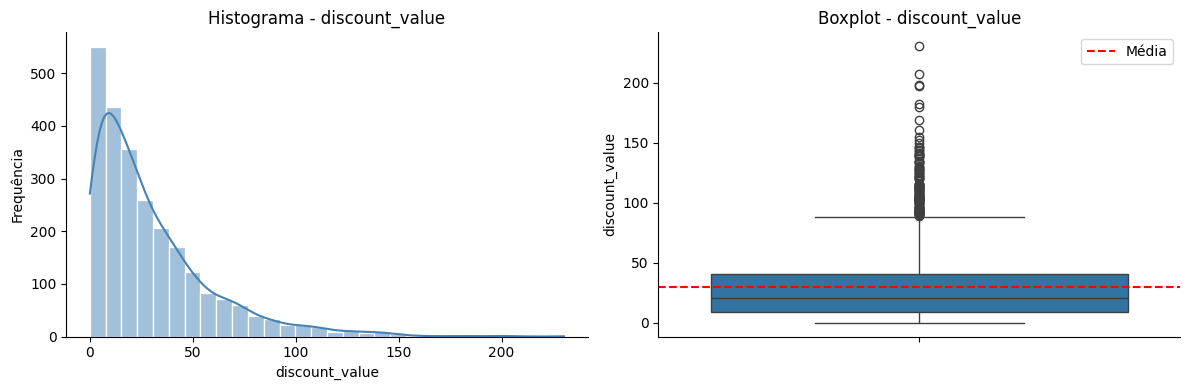

In [36]:
plota_histograma_e_boxplot(df_nps, col)

**Existem ordens em que o valor do desconto é superior ao valor da ordem?**

In [37]:
df_nps[df_nps[col] > df_nps['order_value']].shape[0]

35

In [38]:
df_nps[df_nps[col] > df_nps['order_value']].head(5)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
57,58,54,Sul,101,50058,86.15,2,112.42,11,10,3,36.23,3,1,0,8.4,1,2,5.5
116,117,28,Centro-Oeste,38,50117,60.96,2,95.06,4,9,0,30.19,2,0,7,7.8,0,1,5.2
182,183,41,Sudeste,104,50183,24.00,6,85.49,10,5,2,29.58,3,0,9,4.0,0,4,1.4
270,271,59,Nordeste,80,50271,79.93,2,129.11,6,2,4,27.59,1,1,1,1.1,0,3,4.8


**Conclusão**

- Distribuição assimétrica a esquerda, com alguns outliers a direita. 
- Não existem uma única ordem com nenhum desconto, o menor valor de desconto é 0.02, praticamente 0, mas toda ordem teve ao menos um centavo de desconto. 
- A mediana dos descontos é de aproximadamente 21, enquanto a média é um pouco maior, 29. 
- **Ponto de atenção:** Existem 35 ordens em que o valor de desconto é superior ao valor da ordem.
- **Tratamentos:** Vale a pena a criação de uma coluna da proporção do desconto.

#### 10.6. payment_installments

In [39]:
col = "payment_installments"

In [40]:
df_nps[col].describe().to_frame()

,payment_installments
count,2500.000000
mean,6.004000
std,3.159743
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,11.000000


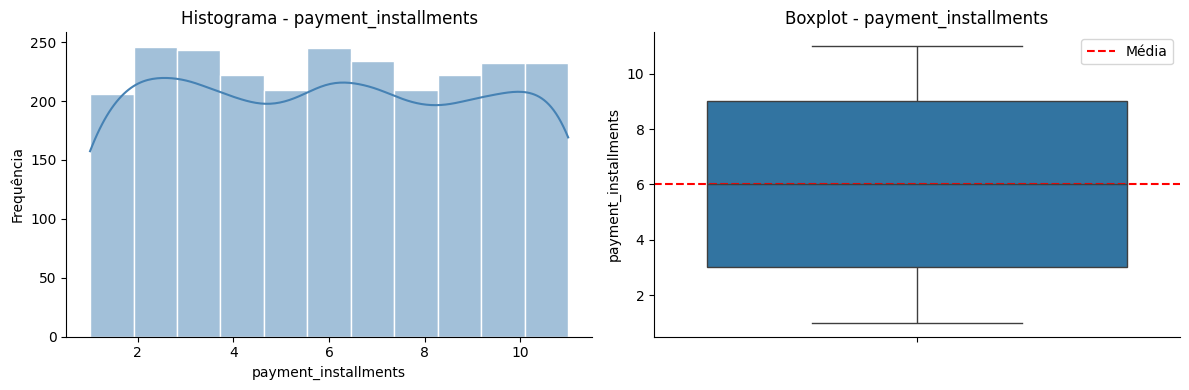

In [41]:
plota_histograma_e_boxplot(df_nps, col, 11)

**Conclusão**

- A coluna identifica o número de parcelas
- Distribuição uniforme, não existe uma concentração em nenhuma quantidade de parcelas específicas. 
- O maior número de parcelas foi de 11, enquanto o menor foi de 1, ou seja, à vista. 
- A média e a mediana foram de 6 parcelas. 

#### 10.7. delivery_time_days

In [42]:
col = "delivery_time_days"

In [43]:
df_nps[col].describe().to_frame()

,delivery_time_days
count,2500.000000
mean,8.022000
std,3.770411
min,2.000000
25%,5.000000
50%,8.000000
75%,11.000000
max,14.000000


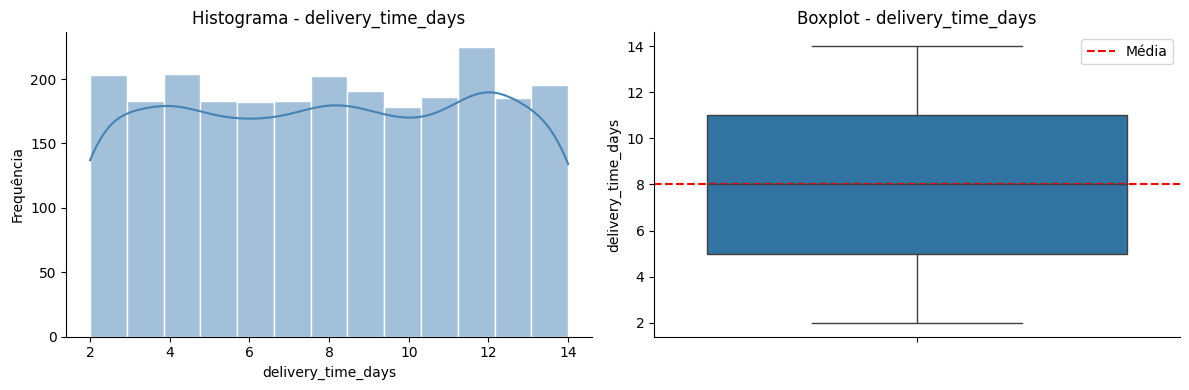

In [44]:
plota_histograma_e_boxplot(df_nps, col, 13)

**Conclusão**

- A coluna identifica o número de dias da entrega. 
- Distribuição uniforme, sem concentração em nenhuma quantidade de dias específica. 
- A entrega mais rápida foi feita em 2 dias, enquanto a mais devagar foi feita em 14 dias. 
- A média, assim como a mediana, foi de 8 dias.

#### 10.8. delivery_delay_days

In [45]:
col = "delivery_delay_days"

In [46]:
df_nps[col].describe().to_frame()

,delivery_delay_days
count,2500.000000
mean,2.187200
std,1.454442
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


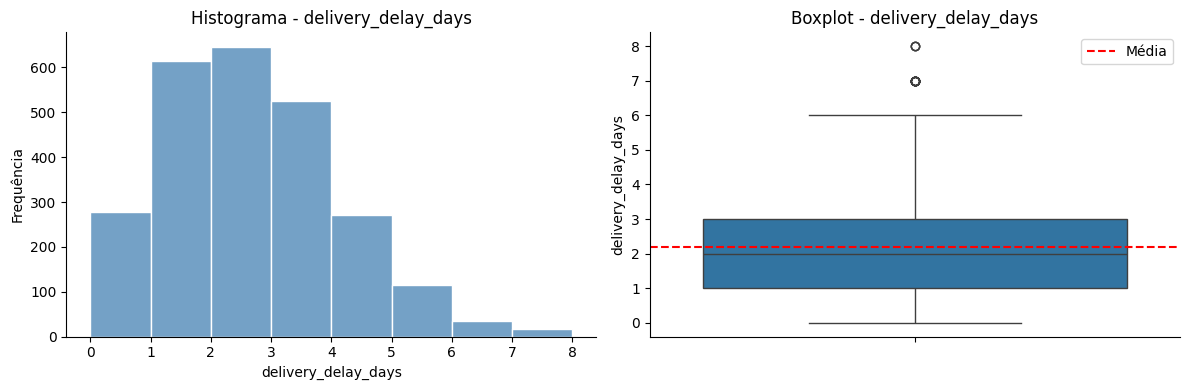

In [47]:
plota_histograma_e_boxplot(df_nps, col, 8, False)

**Conclusão**

- A coluna identifica a Quantidade de dias de atraso na entrega.
- Distribuição normal, com uma leve assimetria a esquerda. 
- **Pontos de atenção:** A maioria dos pedidos teve algum atraso. 
- A média dos pedidos, assim como a mediana, foi de 2 dias de atraso. 
- **Tratamentos:** Vale a pena a criação de uma coluna booleana identificando se houve ou não atraso no pedido. 

#### 10.9. freight_value

In [48]:
col = "freight_value"

In [49]:
df_nps[col].describe().to_frame()

,freight_value
count,2500.000000
mean,38.217016
std,12.076074
min,2.620000
25%,29.927500
50%,38.500000
75%,46.270000
max,76.130000


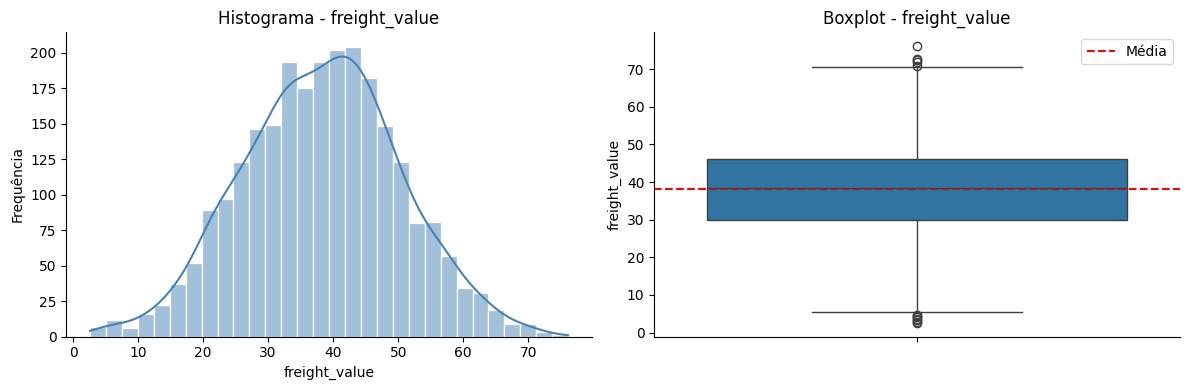

In [50]:
plota_histograma_e_boxplot(df_nps, col)

**Conclusão**

- Identifica o valor do frete.
- Distribuição normal, sem assimetria. 
- Não houve pedidos com frete grátis, o pedido com menor frete teve um frete de 2 reais. 
- A média e mediana do frete foi de 38 reais. 
- **Tratamentos:** Vale a pena a criação da proporção do valor do frete em relação ao valor do pedido. 

#### 10.10. delivery_attempts

In [51]:
col = "delivery_attempts"

In [52]:
df_nps[col].describe().to_frame()

,delivery_attempts
count,2500.000000
mean,2.005600
std,0.815497
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,3.000000


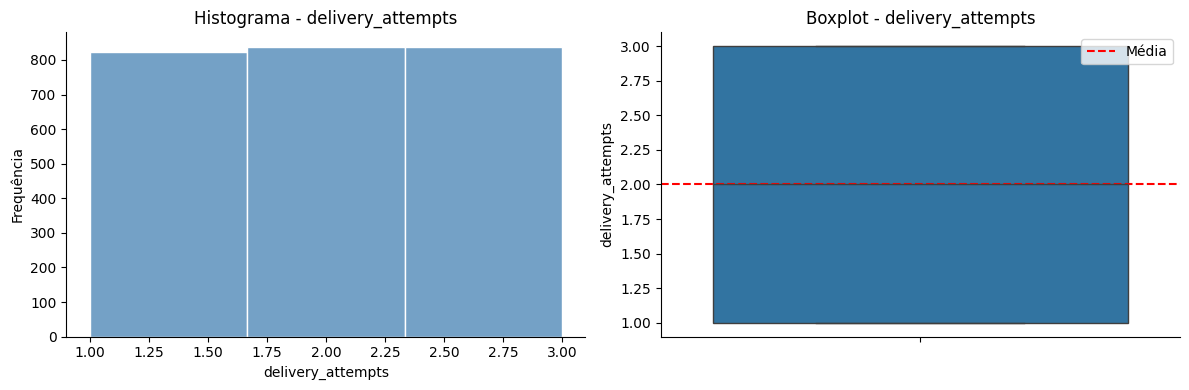

In [53]:
plota_histograma_e_boxplot(df_nps, col, 3, False)

**Conclusão**

- Identifica a quantidade de tentativas de entrega.
- Distribuição uniforme. 
- Os pedidos tiveram no mínimo uma tentativa de entrega, e no máximo três.
- **Ponto de Atenção:** Uma distribuição uniforme para essa informação pode sinalizar um alerta, vale a pena investigar o porque da maioria dos pedidos necessitarem de mais de uma tentativa de entrega.  

#### 10.11. customer_service_contacts

In [54]:
col = "customer_service_contacts"

In [55]:
df_nps[col].describe().to_frame()

,customer_service_contacts
count,2500.000000
mean,1.519600
std,1.231512
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,7.000000


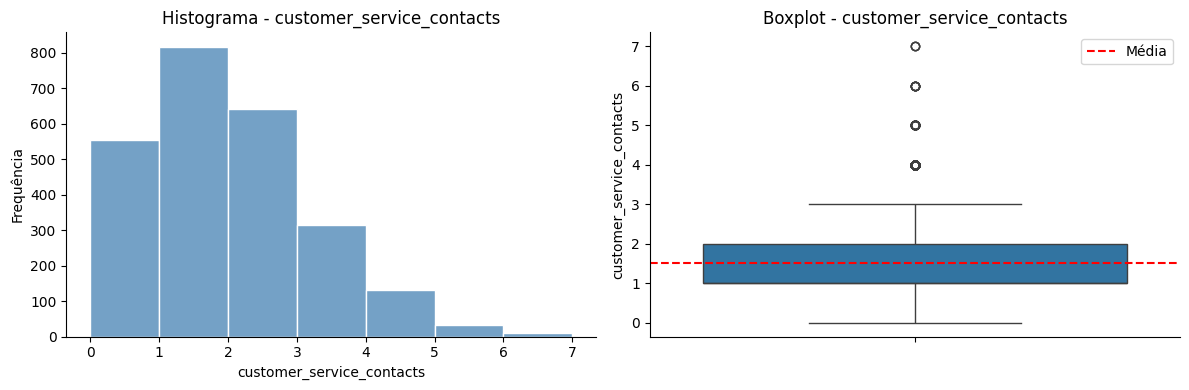

In [56]:
plota_histograma_e_boxplot(df_nps, col, 7, False)

**Conclusão**

- Identifica o Número de contatos do cliente com o atendimento.
- Distribuição normal, com uma leve assimetria a esquerda. 
- A mediana foi de 1 contato, a média foi de 1.5. 
- Menos de um quarto dos pedidos não tiveram nenhum contato com atendimento. 
- Houveram alguns pedidos outliers, com por exemplo 7 contatos com o atendimento.

#### 10.12. resolution_time_days

In [57]:
col = "resolution_time_days"

In [58]:
df_nps[col].describe().to_frame()

,resolution_time_days
count,2500.000000
mean,5.485600
std,3.458002
min,0.000000
25%,2.000000
50%,6.000000
75%,8.000000
max,11.000000


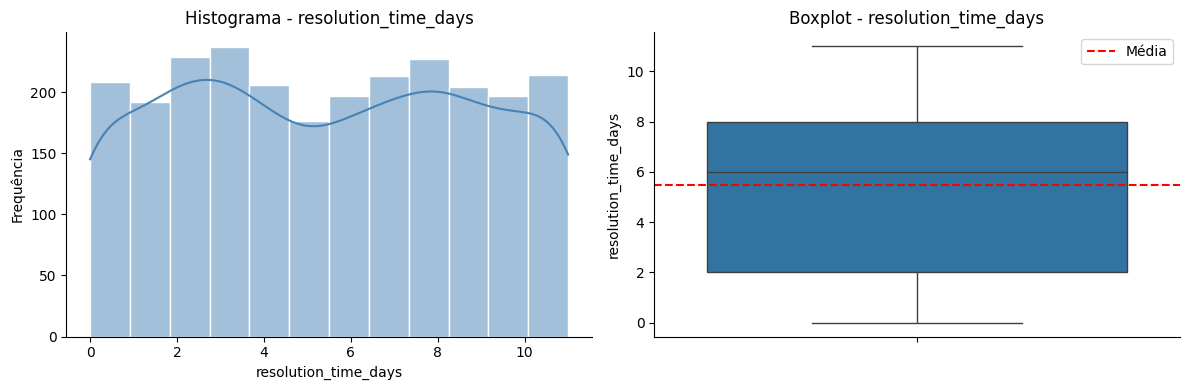

In [59]:
plota_histograma_e_boxplot(df_nps, col, 12)

**Conclusão**

- Identifica o tempo para resolução de problemas.
- Distribuição uniforme. 
- Média e mediana por volta dos 6 dias. 

#### 10.13. nps_score

In [60]:
col = "nps_score"

In [61]:
df_nps[col].describe().to_frame()

,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


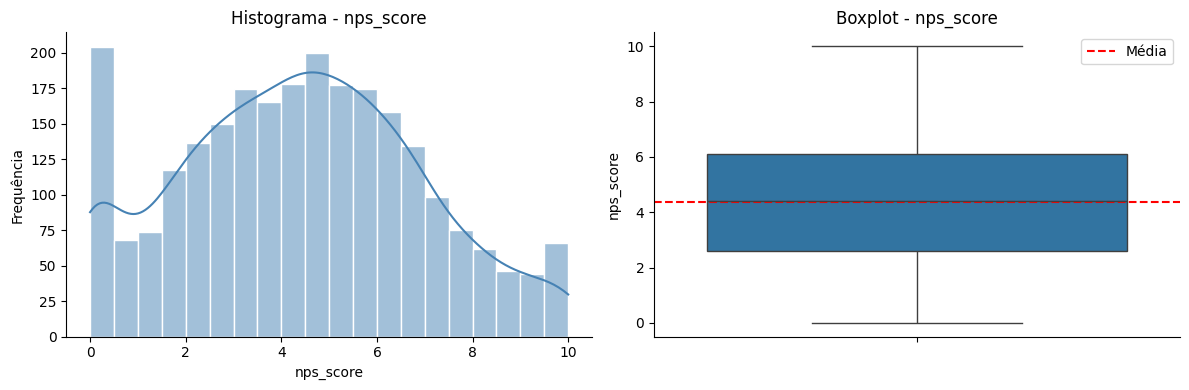

In [62]:
plota_histograma_e_boxplot(df_nps, col, 20)

**Conclusão**

- Variável target da análise. Identifica o NPS atribuído pelo cliente. 
- Distribuição normal, com uma leve exceção na nota 0, que possui uma concentração maior. 
- Média e mediana por volta de 4.4. 
- Considerando os intervalos de notas de NPS, grande maioria dos clientes são detratores. 
- **Tratamentos:** Vale a pena a criação de uma categoria de clientes, classificando-os em Detratores, Neutros e Promotores.  

#### 10.14. complaints_count

In [63]:
col = 'complaints_count'

In [64]:
df_nps[col].describe().to_frame()

,complaints_count
count,2500.000000
mean,4.150400
std,1.784223
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,11.000000


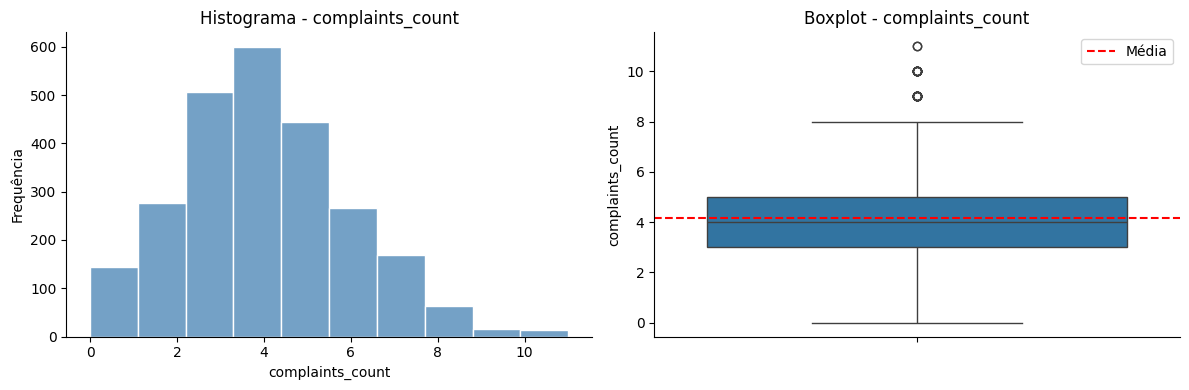

In [65]:
plota_histograma_e_boxplot(df_nps, col, 10, False)

**Conclusão**

- Distribuição normal
- Média e mediana próximas de 4, ou seja, 4 reclamações registradas, número que, de imediato, parece ser bem significativo. 

#### 10.15. csat_internal_score

In [66]:
col = 'csat_internal_score'

In [67]:
df_nps[col].describe().to_frame()

,csat_internal_score
count,2500.000000
mean,2.941600
std,2.378957
min,0.000000
25%,0.700000
50%,2.800000
75%,4.800000
max,10.000000


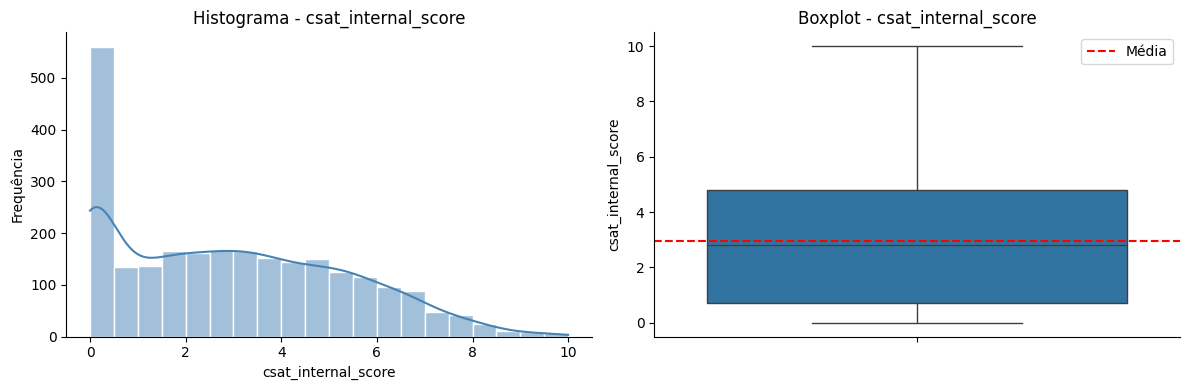

In [68]:
plota_histograma_e_boxplot(df_nps, col, 20)

**Conclusão**

- Nota interna de satisfação do cliente. 
- Distribuição uniforme, mas com uma grande concentração nas notas entre 0 e 1. 
- Media e mediana por volta de 3. 
- Score interno parece ser "confirmado" pela nota do cliente. 